# A-adathalmaz Steam Store Games (Clean dataset)

## Cél
Ez a munkafüzet a `data/A/steam.csv` adatállomány feltáró elemzését mutatja be.
A fókusz az árakra, a megjelenési mintázatokra, a műfajokra, valamint az értékelési mutatókra és azok eloszlására esik.

## Főbb lépések
- adatok betöltése és gyors áttekintése
- időbeli trendek (árak, megjelenések)
- kategorikus eloszlások (műfaj, korhatár, platform)
- pozitív értékelési arány vizsgálata több nézőpontból



## 1. Adatbetöltés és előkészítés
Ebben a részben betöltöm a függőségeket, listázom az elérhető fájlokat, majd beolvasom az alapadatokat.


In [1]:
from collections import Counter
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib_venn import venn3
from scipy.stats import kruskal, mannwhitneyu, pearsonr, spearmanr



In [2]:
data_dir = Path("../../data/A")
required_main_file = data_dir / "steam.csv"

if not data_dir.exists():
    raise FileNotFoundError(f"Missing data directory: {data_dir.resolve()}")

csv_files = sorted(data_dir.glob("*.csv"))
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in: {data_dir.resolve()}")

if not required_main_file.exists():
    raise FileNotFoundError(f"Missing required file: {required_main_file.resolve()}")

rows = []
for f in csv_files:
    table_df = pd.read_csv(f, low_memory=False)
    rows.append({
        "table": f.name,
        "records": table_df.shape[0],
        "attributes": table_df.shape[1],
    })

summary = pd.DataFrame(rows).sort_values("table")
display(summary)


,table,records,attributes
0,steam.csv,27075,18
1,steam_description_data.csv,27334,4
2,steam_description_data_cleaned.csv,27334,4
3,steam_media_data.csv,27332,5
4,steam_requirements_data.csv,27319,6
5,steam_support_info.csv,27136,4
6,steamspy_tag_data.csv,29022,372


### Adatforrások gyors áttekintése
A következő kódcella összegzi a `data/A` mappában található CSV-állományokat és azok méretét.


In [3]:
csv_path = Path("../../data/A/steam.csv")

df = pd.read_csv(csv_path)
print("CSV loaded successfully!")
display(df.head(10))
print("Number of records:", df.shape[0])
print("Number of attributes:", df.shape[1])


CSV loaded successfully!


,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99
5,60,Ricochet,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Valve Anti-Ch...,Action,Action;FPS;Multiplayer,0,2758,684,175,10,5000000-10000000,3.99
6,70,Half-Life,1998-11-08,1,Valve,Valve,windows;mac;linux,0,Single-player;Multi-player;Online Multi-Player...,Action,FPS;Classic;Action,0,27755,1100,1300,83,5000000-10000000,7.19
7,80,Counter-Strike: Condition Zero,2004-03-01,1,Valve,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,Action;FPS;Multiplayer,0,12120,1439,427,43,10000000-20000000,7.19
8,130,Half-Life: Blue Shift,2001-06-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player,Action,FPS;Action;Sci-fi,0,3822,420,361,205,5000000-10000000,3.99
9,220,Half-Life 2,2004-11-16,1,Valve,Valve,windows;mac;linux,0,Single-player;Steam Achievements;Steam Trading...,Action,FPS;Action;Sci-fi,33,67902,2419,691,402,10000000-20000000,7.19


Number of records: 27075
Number of attributes: 18


## 2. Feltáró vizualizációs elemzések
Az alábbi alfejezetek különböző nézőpontokból mutatják be a Steam-játékok fontosabb mintázatait.


### Játékok átlagos ára évenként a Steamen

Ez a szakasz a játékok átlagos árának alakulását vizsgálja évenként a Steam platformon. A kód kiszámolja az átlagárat minden évre, majd egy vonaldiagramon jeleníti meg az eredményt, hogy láthatóvá váljon az árak időbeli trendje.


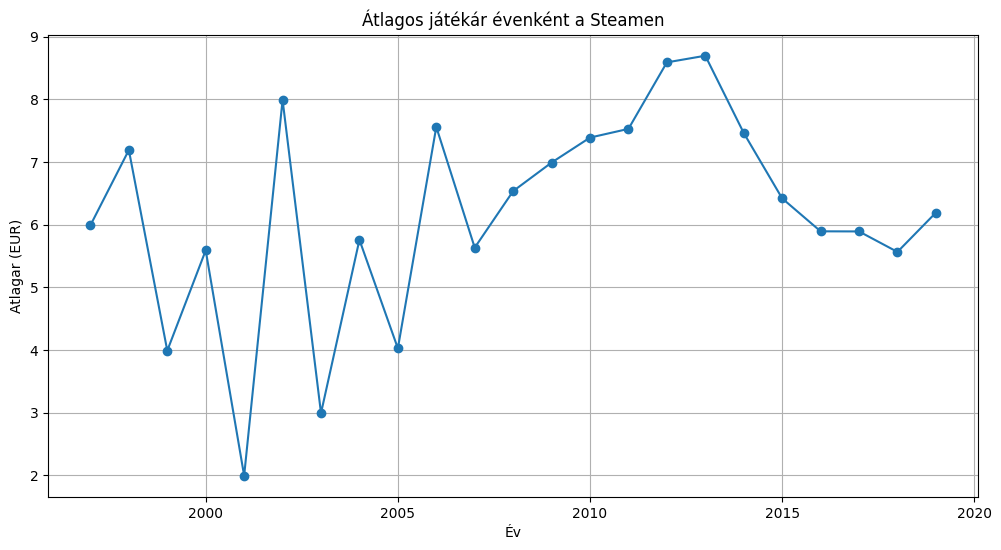

In [4]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["year"] = df["release_date"].dt.year

year_price = df.groupby("year")["price"].mean()

plt.figure(figsize=(12,6))
plt.plot(year_price.index, year_price.values, marker="o")
plt.title("Átlagos játékár évenként a Steamen")
plt.xlabel("Év")
plt.ylabel("Atlagar (EUR)")
plt.grid(True)
out_base = Path("notebooks") if Path("notebooks").exists() else Path(".")
out_dir = out_base / "generated" / "A"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "mean.png")
plt.show()

A vonaldiagramon az éves átlagár látható. A görbe alapján azonosíthatók azok az időszakok, amikor a Steam kínálat átlagos ára emelkedett vagy visszaesett.


### Játék megjelenések száma évenként és hónaponként (Hőtérkép)

Ez a szakasz a játékok megjelenésének mintázatát vizsgálja évenként és hónaponként egy hőtérkép segítségével. A kód összesíti a megjelenések számát minden hónapban az egyes években, majd a hőtérkép vizuálisan megjeleníti a sűrűbben és ritkábban előforduló megjelenési időszakokat.


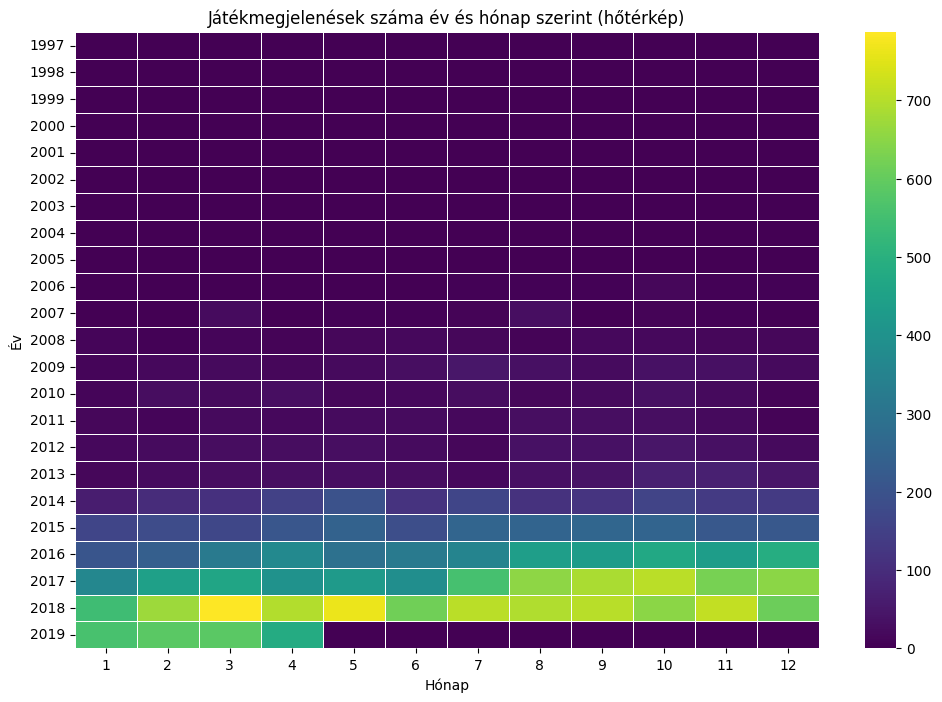

In [5]:
df["month"] = df["release_date"].dt.month
releases_heatmap_data = df.groupby(["year", "month"]).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(releases_heatmap_data, cmap="viridis", fmt="d", linewidths=.5)
plt.title("Játékmegjelenések száma év és hónap szerint (hőtérkép)")
plt.xlabel("Hónap")
plt.ylabel("Év")
plt.show()

A hőtérképen az év–hónap bontású megjelenésszám látható. A sötétebb mezők nagyobb kiadási aktivitást jeleznek, így kirajzolódnak a szezonális csúcsok.


### Játék árak eloszlása

Ez a szakasz a játékok árának eloszlását vizsgálja a Steam platformon. A kód egy hisztogramot készít, amely bemutatja, milyen gyakran fordulnak elő bizonyos ártartományok a játékok között.


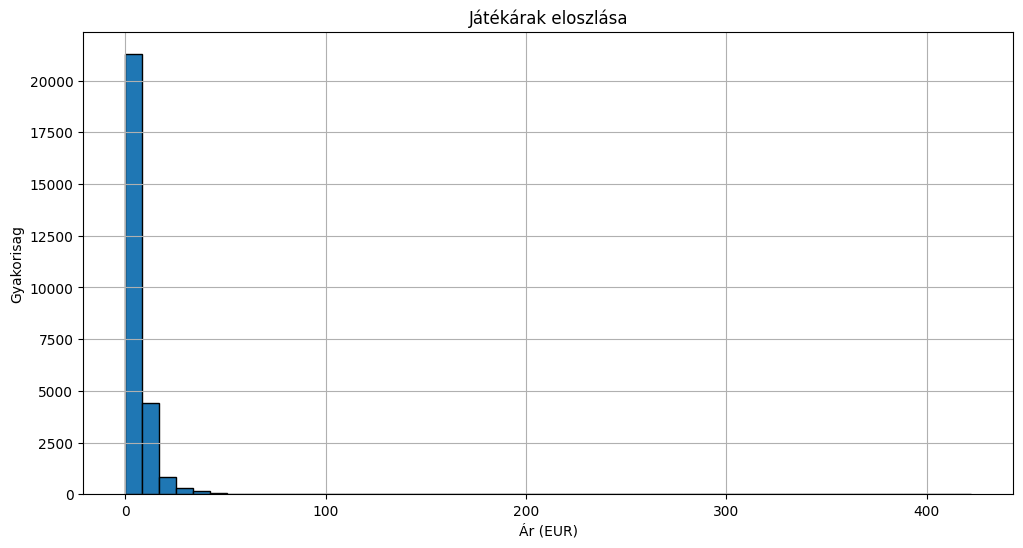

In [6]:
plt.figure(figsize=(12, 6))
plt.hist(df["price"], bins=50, edgecolor="black")
plt.title("Játékárak eloszlása")
plt.xlabel("Ár (EUR)")
plt.ylabel("Gyakorisag")
plt.grid(True)
plt.show()

A hisztogram a teljes ármező eloszlását mutatja. A legmagasabb oszlopok azokban az ársávokban jelennek meg, ahol a legtöbb játék található.


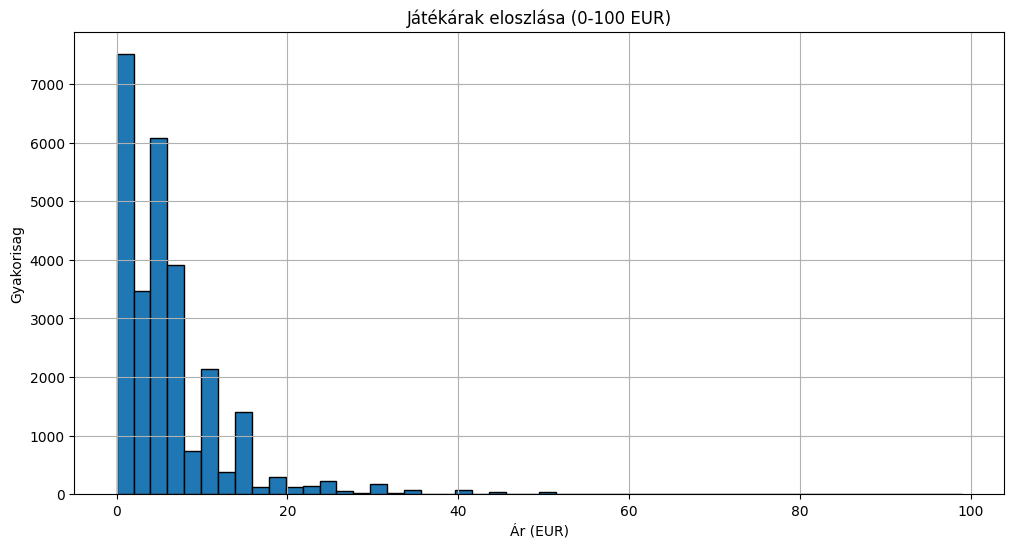

In [7]:
df_filtered_price = df[(df["price"] >= 0) & (df["price"] <= 100)]

plt.figure(figsize=(12, 6))
plt.hist(df_filtered_price["price"], bins=50, edgecolor="black")
plt.title("Játékárak eloszlása (0-100 EUR)")
plt.xlabel("Ár (EUR)")
plt.ylabel("Gyakorisag")
plt.grid(True)
plt.show()

Ez az ábra a 0–100 EUR közötti árakat mutatja részletesen. Jól látszik, mely árszintek a leggyakoribbak a tipikus, nem szélsőséges tartományban.


### Játékok száma évenként

Ez a szakasz a Steam-en megjelenő játékok számának alakulását vizsgálja évenként. A kód megszámolja a játékok számát minden évre, majd egy oszlopdiagramon jeleníti meg az eredményt, hogy láthatóvá váljon a megjelenések számának időbeli trendje.


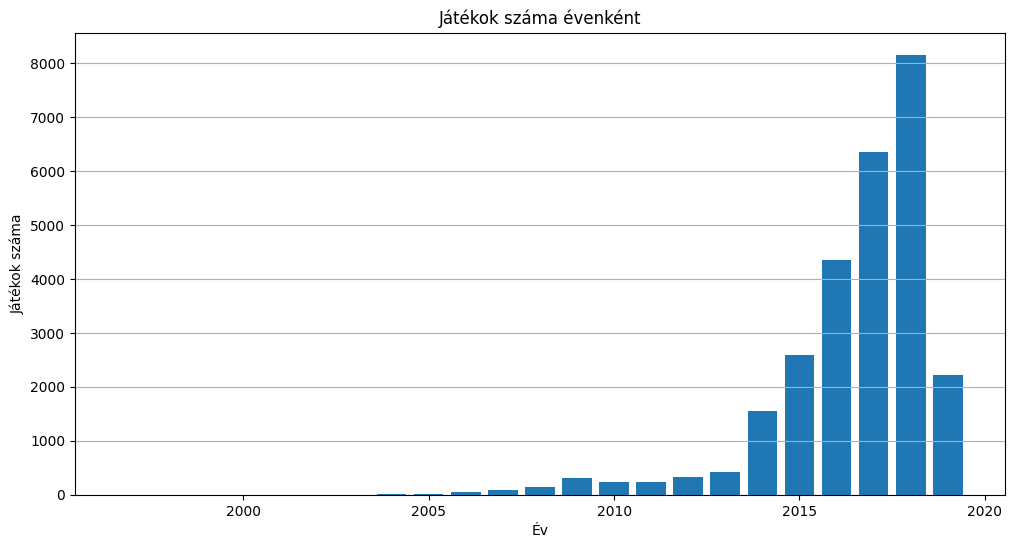

In [8]:
if "year" not in df.columns:
    df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
    df["year"] = df["release_date"].dt.year

games_per_year = df["year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.bar(games_per_year.index, games_per_year.values)
plt.title("Játékok száma évenként")
plt.xlabel("Év")
plt.ylabel("Játékok száma")
plt.grid(axis="y")
plt.show()

Az oszlopdiagram az évente megjelent játékok számát mutatja. Az eltérő oszlopmagasságokból látszik, mely években volt erősebb a megjelenési volumen.


### Top 20 Játék Műfaj Száma

Ez a szakasz a leggyakoribb játék műfajokat vizsgálja a Steam-en. A kód kinyeri az összes műfajt a datasetből, megszámolja az egyes műfajok előfordulását, majd egy oszlopdiagramon megjeleníti a 20 leggyakoribb műfajt.


<Figure size 1200x800 with 0 Axes>

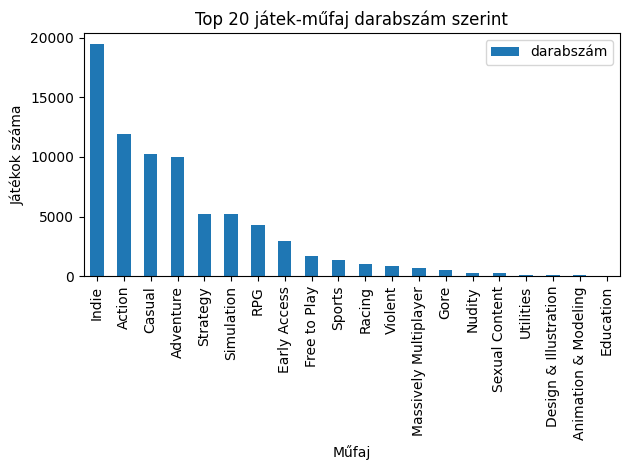

In [9]:
genres_list = df["genres"].str.split(";").sum()
genre_counts = Counter(genres_list)

genre_df = pd.DataFrame.from_dict(genre_counts, orient="index", columns=["darabszám"]).sort_values(by="darabszám", ascending=False)

top_n = 20
plt.figure(figsize=(12, 8))
genre_df.head(top_n).plot(kind="bar")
plt.title(f"Top {top_n} játek-műfaj darabszám szerint")
plt.xlabel("Műfaj")
plt.ylabel("Játékok száma")
plt.xticks(rotation=90)
plt.tight_layout()
out_base = Path("notebooks") if Path("notebooks").exists() else Path(".")
out_dir = out_base / "generated" / "A"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / f"top{top_n}.png")
plt.show()

Az ábra a 20 leggyakoribb műfaj előfordulását mutatja. Egyértelműen elkülönülnek a domináns műfajok és a ritkábban megjelenő kategóriák.


### Játékok száma az ajánlott életkor szerint

Ez a szakasz a játékok számának eloszlását vizsgálja az ajánlott életkor szerint a Steam-en. A kód megszámolja a játékok számát minden korosztályra, majd egy oszlopdiagramon jeleníti meg az eredményt, hogy láthatóvá váljon a korosztály szerinti megoszlás.


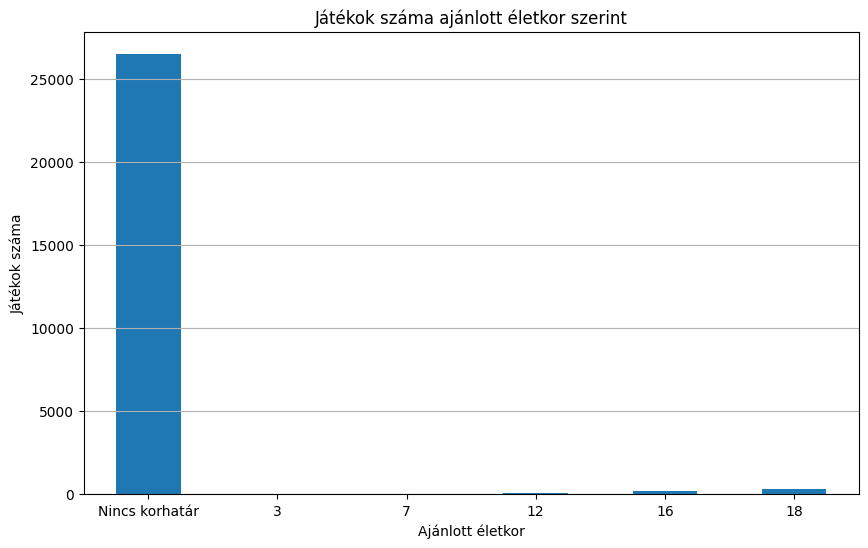

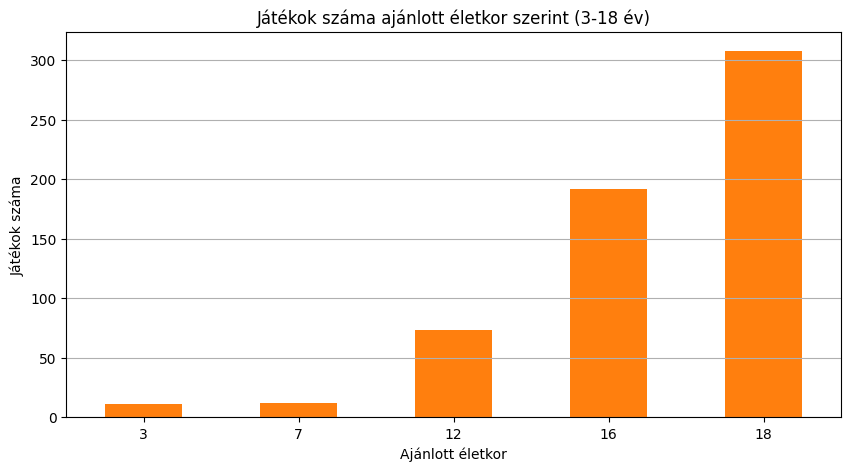

In [10]:
age_counts_raw = df["required_age"].value_counts().sort_index()

age_counts = age_counts_raw.rename(index={0: "Nincs korhatár"})

plt.figure(figsize=(10, 6))
age_counts.plot(kind="bar")
plt.title("Játékok száma ajánlott életkor szerint")
plt.xlabel("Ajánlott életkor")
plt.ylabel("Játékok száma")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

small_age_counts = age_counts_raw[(age_counts_raw.index >= 3) & (age_counts_raw.index <= 18)]

if not small_age_counts.empty:
    plt.figure(figsize=(10, 5))
    small_age_counts.plot(kind="bar", color="tab:orange")
    plt.title("Játékok száma ajánlott életkor szerint (3-18 év)")
    plt.xlabel("Ajánlott életkor")
    plt.ylabel("Játékok száma")
    plt.xticks(rotation=0)
    plt.grid(axis="y")
    plt.show()


Az első diagram a teljes korhatár-eloszlást mutatja, beleértve a domináns "Nincs korhatár" kategóriát.
A második, külön ábra a 3–18 éves korhatár-sávra fókuszál, így a kisebb elemszámú oszlopok közti különbségek is jól láthatók.


### Játékok száma támogatott platformonként

Ez a szakasz a játékok platformtámogatását vizsgálja a Steam-en. A kód megszámolja, hány játék érhető el Windows, Mac és Linux platformon, majd egy oszlopdiagramon megjeleníti az eredményt, hogy láthatóvá váljon a platform szerinti megoszlás.


<Figure size 1000x600 with 0 Axes>

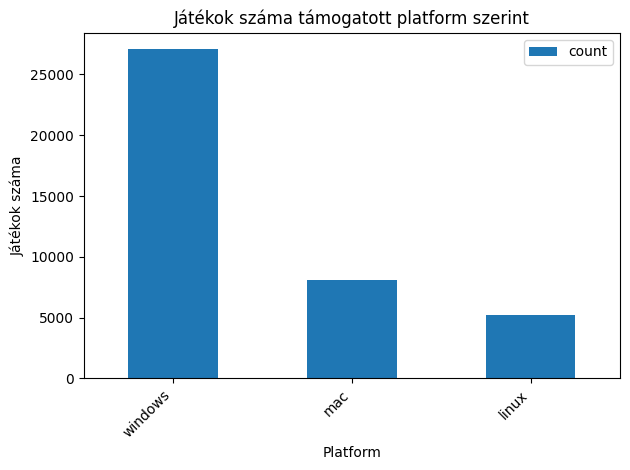

In [11]:
platforms_list = df["platforms"].str.split(";").sum()
platform_counts = Counter(platforms_list)

platform_df = pd.DataFrame.from_dict(platform_counts, orient="index", columns=["count"]).sort_values(by="count", ascending=False)

plt.figure(figsize=(10, 6))
platform_df.plot(kind="bar")
plt.title("Játékok száma támogatott platform szerint")
plt.xlabel("Platform")
plt.ylabel("Játékok száma")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

Az oszlopok a platformonként elérhető játékok számát mutatják. Így közvetlenül összehasonlítható a Windows, Mac és Linux támogatás aránya.


### Platform együttjárás: kereszttábla és feltételes valószínűségek

Ebben a részben a Windows, Mac és Linux támogatások együttes előfordulását vizsgálom.
A kereszttábla a platform-kombinációk darabszámát mutatja, majd kiszámolom a feltételes valószínűségeket is (például P(Mac | Windows)).
Ha a `matplotlib-venn` csomag elérhető, egy Venn-diagram is megjelenik.


,windows,mac,linux,count
0,1,0,0,18398
1,1,1,1,4623
2,1,1,0,3439
3,1,0,1,610
4,0,1,0,3
5,0,1,1,1
6,0,0,1,1


,windows,mac,linux
windows,100.00%,29.78%,19.33%
mac,99.95%,100.00%,57.33%
linux,99.96%,88.33%,100.00%


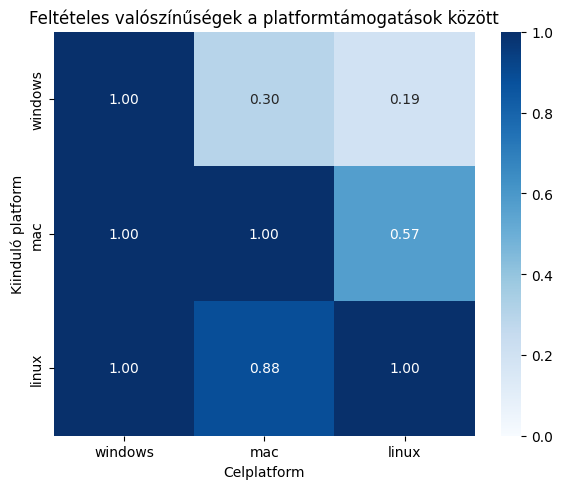

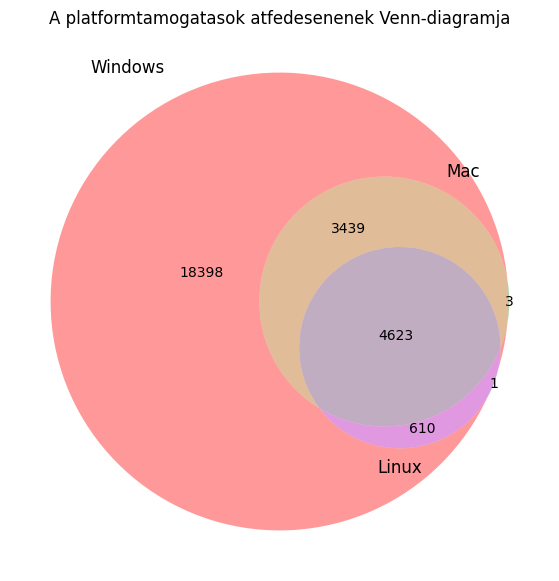

In [12]:
platform_flags = df["platforms"].fillna("").str.get_dummies(sep=";")
target_platforms = [col for col in ["windows", "mac", "linux"] if col in platform_flags.columns]

if len(target_platforms) < 2:
    raise ValueError("Not enough platform columns found for cross-tab analysis.")

platform_flags = platform_flags[target_platforms].astype(int)

combo_counts = (
    platform_flags
    .value_counts()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)
display(combo_counts)

cond_matrix = pd.DataFrame(index=target_platforms, columns=target_platforms, dtype=float)
for given_plat in target_platforms:
    given_mask = platform_flags[given_plat] == 1
    for target_plat in target_platforms:
        if given_mask.sum() == 0:
            cond_matrix.loc[given_plat, target_plat] = float("nan")
        else:
            cond_matrix.loc[given_plat, target_plat] = platform_flags.loc[given_mask, target_plat].mean()

display(cond_matrix.style.format("{:.2%}"))

plt.figure(figsize=(6, 5))
sns.heatmap(cond_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1)
plt.title("Feltételes valószínűségek a platformtámogatások között")
plt.xlabel("Celplatform")
plt.ylabel("Kiinduló platform")
plt.tight_layout()
plt.show()

if set(["windows", "mac", "linux"]).issubset(set(target_platforms)):
        w = platform_flags["windows"] == 1
        m = platform_flags["mac"] == 1
        l = platform_flags["linux"] == 1

        subsets = (
            int((w & ~m & ~l).sum()),  # 100
            int((~w & m & ~l).sum()),  # 010
            int((w & m & ~l).sum()),   # 110
            int((~w & ~m & l).sum()),  # 001
            int((w & ~m & l).sum()),   # 101
            int((~w & m & l).sum()),   # 011
            int((w & m & l).sum()),    # 111
        )

        plt.figure(figsize=(7, 7))
        venn3(subsets=subsets, set_labels=("Windows", "Mac", "Linux"))
        plt.title("A platformtamogatasok atfedesenenek Venn-diagramja")
        plt.show()


A kombinációs kereszttábla megmutatja, mely platform-párosítások/hármasok fordulnak elő leggyakrabban.
A feltételes valószínűségi mátrixból közvetlenül leolvasható például, hogy Windows-támogatás mellett mekkora eséllyel van Mac vagy Linux támogatás is.


### Pozitív értékelési arány az ár függvényében

Ez a szakasz a játékok pozítiv értékelési aránya és az ár közötti kapcsolatot vizsgálja. A kód egy kétváltozós hisztogramot (2D histplot) használ az adatok megjelenítésére, amely a játékok árát (EUR-ban) és a pozitív értékelések arányát (%) ábrázolja.


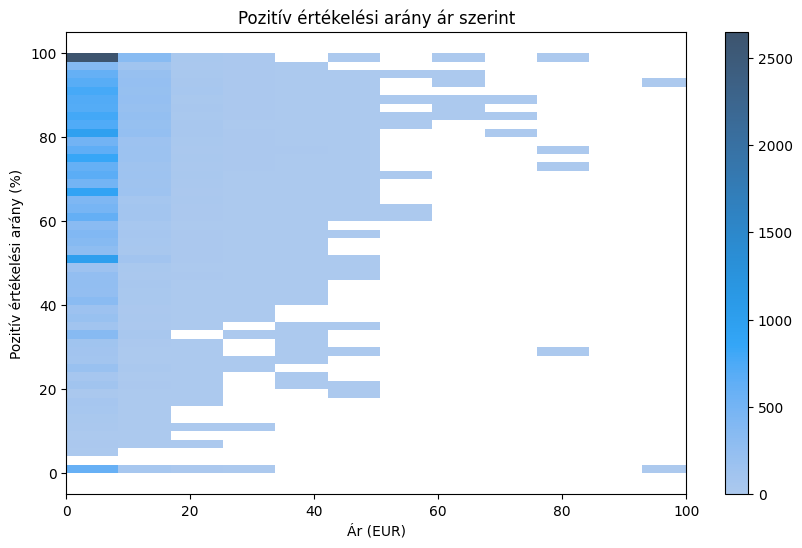

In [13]:
df["rating_percent"] = df["positive_ratings"] / (df["positive_ratings"] + df["negative_ratings"]) * 100

plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x="price",
    y="rating_percent",
    bins=(50, 50),
    cbar=True
)
plt.xlim(0, 100)
plt.title("Pozitív értékelési arány ár szerint")
plt.xlabel("Ár (EUR)")
plt.ylabel("Pozitív értékelési arány (%)")
plt.show()

A kétdimenziós hisztogram az ár és a pozitív értékelési arány kapcsolatát mutatja. A legsűrűbb területek jelzik, mely ár–értékelés kombinációk a leggyakoribbak.


### Pozitív értékelési arány az ár függvényében

Ebben a szakaszban a Steam-játékok pozitív értékelési aránya és ára közötti összefüggést vizsgálom.
A kód egy hexbin-diagramot hoz létre, amely hatszög alakú cellákban ábrázolja az adatpontok sűrűségét.

A vízszintes tengelyen a játékok ára (EUR-ban), a függőleges tengelyen pedig a pozitív értékelések aránya (%) látható.
A cellák színe a pontsűrűséget mutatja logaritmikus skálán: a sötétebb árnyalatok több játékot jeleznek az adott ár–értékelési arány kombinációban.


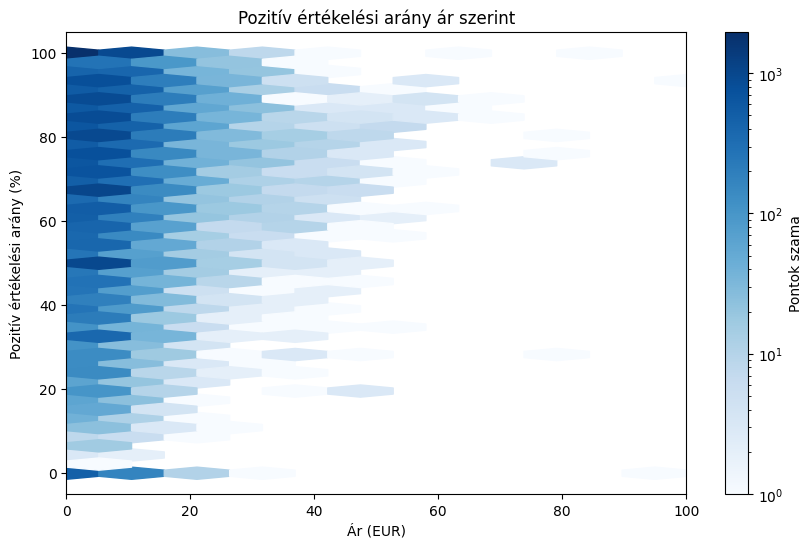

In [14]:
plt.figure(figsize=(10,6))
plt.hexbin(
    df["price"],
    df["rating_percent"],
    gridsize=40,
    cmap="Blues",
    bins="log"
)
plt.xlim(0, 100)
plt.colorbar(label="Pontok szama")
plt.title("Pozitív értékelési arány ár szerint")
plt.xlabel("Ár (EUR)")
plt.ylabel("Pozitív értékelési arány (%)")
plt.show()


A hexbin ábra ugyanennek a kapcsolatnak a sűrűségi képét adja. A sötétebb hatszögekben több játék koncentrálódik az adott ár és értékelési arány mellett.


### Számszerű összegzés: ár és értékelési arány kapcsolata

Az alábbi blokk statisztikailag is ellenőrzi, hogy van-e szignifikáns kapcsolat az ár és a pozitív értékelési arány között.
A Pearson-korreláció lineáris, a Spearman-korreláció monoton kapcsolatot mér.


In [15]:
analysis_df = df[["price", "rating_percent"]].replace([np.inf, -np.inf], np.nan).dropna()
analysis_df = analysis_df[(analysis_df["price"] >= 0) & (analysis_df["price"] <= 100)]
analysis_df = analysis_df[(analysis_df["rating_percent"] >= 0) & (analysis_df["rating_percent"] <= 100)]

x = analysis_df["price"].to_numpy()
y = analysis_df["rating_percent"].to_numpy()
n = len(analysis_df)

if n < 3:
    raise ValueError("Not enough valid rows for statistical testing.")

pearson_r = np.corrcoef(x, y)[0, 1]
spearman_rho = pd.Series(x).corr(pd.Series(y), method="spearman")

pearson_r, pearson_p = pearsonr(x, y)
spearman_rho, spearman_p = spearmanr(x, y)

slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept
ss_res = np.sum((y - y_pred) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r_squared = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

print(f"Valid sample size: {n}")
print(f"Pearson r: {pearson_r:.4f}")
print(f"Pearson p-value: {pearson_p:.6g}")

print(f"Spearman rho: {spearman_rho:.4f}")
print(f"Spearman p-value: {spearman_p:.6g}")

print(f"Linear slope (rating% per 1 EUR): {slope:.4f}")
print(f"Linear model R-squared: {r_squared:.4f}")

alpha = 0.05
signif_text = "significant" if pearson_p < alpha else "not significant"
print(f"Conclusion (Pearson, alpha=0.05): relationship is {signif_text}.")

effect = abs(pearson_r)
if effect < 0.10:
    effect_label = "negligible"
elif effect < 0.30:
    effect_label = "weak"
elif effect < 0.50:
    effect_label = "moderate"
else:
    effect_label = "strong"
print(f"Effect size by |r|: {effect_label}.")


Valid sample size: 27064
Pearson r: 0.0876
Pearson p-value: 2.94964e-47
Spearman rho: 0.1220
Spearman p-value: 2.64982e-90
Linear slope (rating% per 1 EUR): 0.3062
Linear model R-squared: 0.0077
Conclusion (Pearson, alpha=0.05): relationship is significant.
Effect size by |r|: negligible.


### Pozitív értékelési arány a korhatár függvényében

Ez a szakasz azt vizsgálja, hogyan alakul a Steam-játékok pozitív értékelési aránya a különböző korhatár-besorolások szerint.
A kód egy boxplotot (dobozdiagramot) használ, amely az egyes korhatárokhoz tartozó eloszlásokat mutatja be.


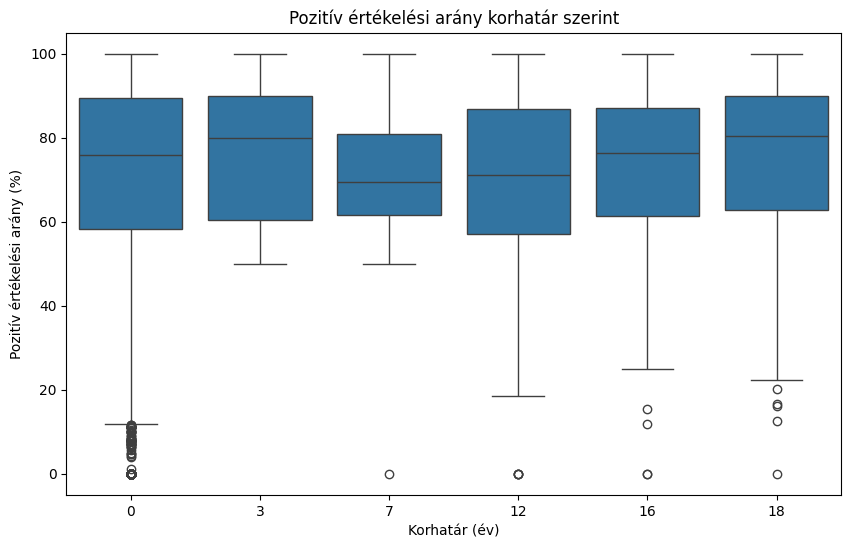

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="required_age", y="rating_percent")
plt.title("Pozitív értékelési arány korhatár szerint")
plt.xlabel("Korhatár (év)")
plt.ylabel("Pozitív értékelési arány (%)")
plt.show()

A dobozdiagram korhatár szerint mutatja a pozitív értékelési arány mediánját és szóródását. Jól látható, hogy egyes korcsoportoknál szűkebb vagy szélesebb az eloszlás.


### Pozitív értékelési arány eloszlása a kiadási év függvényében

Ez a szakasz a Steam-játékok pozitív értékelési arányának eloszlását vizsgálja a kiadási év függvényében.
A kód egy violin plotot készít, amely a különböző évekhez tartozó értékelési arányok eloszlását mutatja.


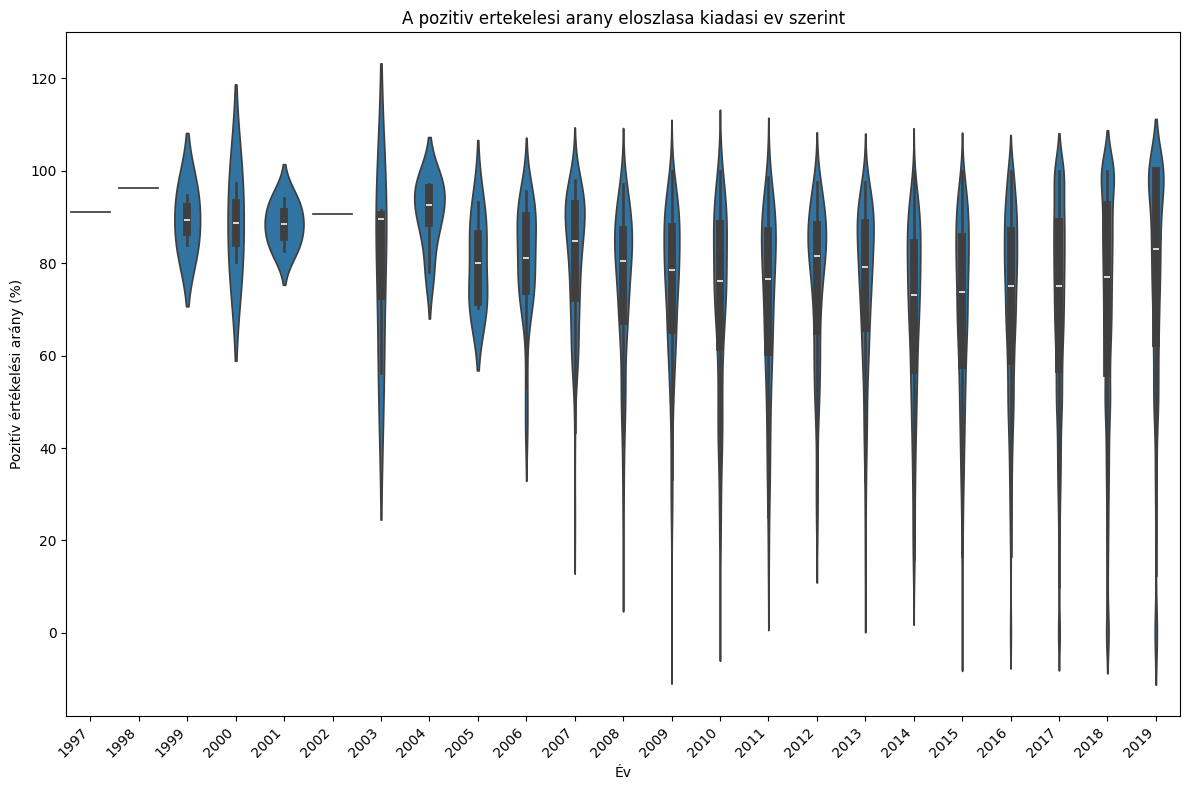

In [17]:
plt.figure(figsize=(12, 8))
sns.violinplot(data=df, x="year", y="rating_percent")
plt.title("A pozitiv ertekelesi arany eloszlasa kiadasi ev szerint")
plt.xlabel("Év")
plt.ylabel("Pozitív értékelési arány (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

A violin ábra évenként mutatja az értékelési arányok eloszlását. A szélesebb részek nagyobb adatsűrűséget jeleznek, így látszik, mely években koncentrálódtak hasonló értékek.


### Pozitív értékelések eloszlása korhatáronként

Ebben a szakaszban a Steam-játékok pozitív értékelési arányának eloszlását vizsgálom a korhatár-besorolás szerint.
A kód egy FacetGrid segítségével több hisztogramot készít, ahol minden panel egy adott korhatárhoz tartozó játékok eloszlását mutatja.


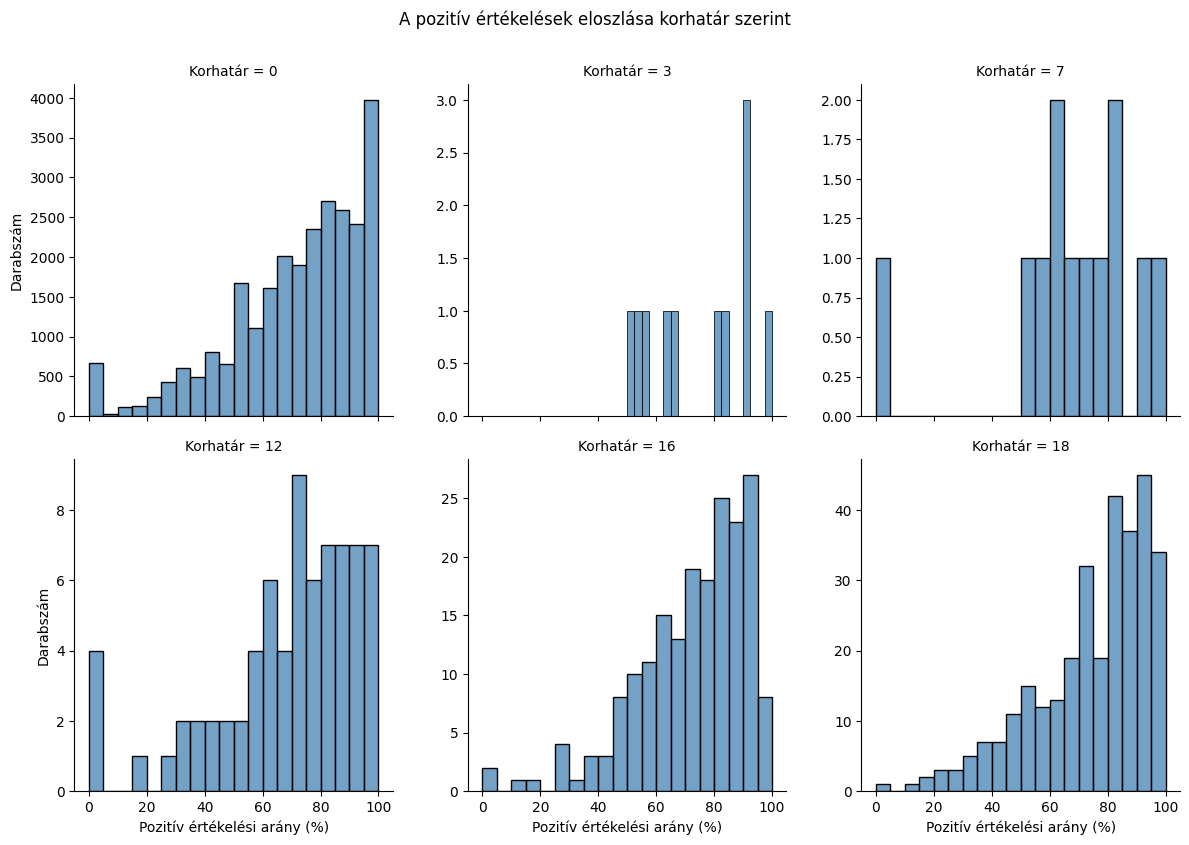

In [18]:
g = sns.FacetGrid(df, col="required_age", col_wrap=3, height=4, sharex=True, sharey=False)
g.map_dataframe(sns.histplot, x="rating_percent", bins=20, color="steelblue")
g.set_titles("Korhatár = {col_name}")
g.set_axis_labels("Pozitív értékelési arány (%)", "Darabszám")
plt.suptitle("A pozitív értékelések eloszlása korhatár szerint", y=1.05)
plt.show()

A paneles hisztogramok korhatáronként külön mutatják az értékelési arány eloszlását.
A külön függőleges skála miatt a kisebb elemszámú csoportok mintázata is jól látható.


### Pozitív értékelések eloszlása a korhatár függvényében

Ez a szakasz a Steam-játékok pozitív értékelési arányának eloszlását mutatja be a korhatár-besorolások szerint.
A kód egy kernel-sűrűségbecslést (KDE-plot) alkalmaz, amely simított görbékkel ábrázolja az értékelési arányok eloszlását minden korosztály esetében.


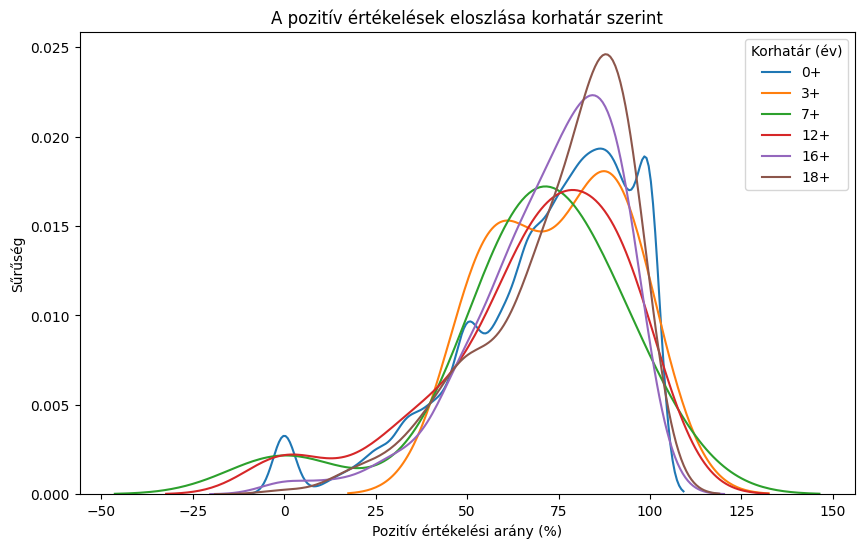

In [19]:
plt.figure(figsize=(10,6))
for age in sorted(df["required_age"].unique()):
    subset = df[df["required_age"] == age]
    sns.kdeplot(subset["rating_percent"], label=f"{age}+")
plt.title("A pozitív értékelések eloszlása korhatár szerint")
plt.xlabel("Pozitív értékelési arány (%)")
plt.ylabel("Sűrűség")
plt.legend(title="Korhatár (év)")
plt.show()

A KDE-görbék a korhatár-csoportok simított eloszlását mutatják. A csúcsok alapján látszik, mely értékelési tartományok a legjellemzőbbek az egyes csoportokban.


### Pozitív értékelések eloszlása a korhatár függvényében

Ebben a szakaszban a Steam-játékok pozitív értékelési arányának eloszlását vizsgálom a különböző korhatár-besorolások mentén.
A kód egy violin plotot használ, amely a sűrűségeloszlást és a boxplot statisztikáit egyesíti.


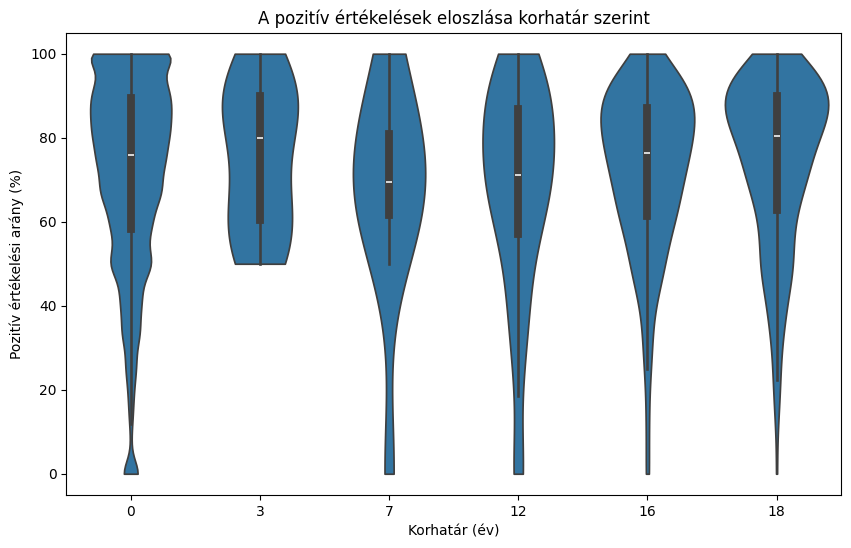

In [20]:
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="required_age", y="rating_percent", inner="box", cut=0)
plt.title("A pozitív értékelések eloszlása korhatár szerint")
plt.xlabel("Korhatár (év)")
plt.ylabel("Pozitív értékelési arány (%)")
plt.show()

Ez a violin ábra egyszerre mutatja a sűrűséget és az alapstatisztikákat korhatár szerint. Jól követhető, hol koncentrálódnak az értékelések és mekkora a szórás csoportonként.


### Eloszlás-egyezés statisztikai ellenőrzése korhatár-csoportok között

Ebben a blokkban formálisan is tesztelem, hogy a korhatár-csoportok értékelési eloszlásai tekinthetők-e azonosnak.
Globális tesztként Kruskal–Wallis-próbát használok, majd páronkénti Mann–Whitney teszteket is futtatok Holm-korrekcióval.


In [21]:
alpha = 0.05
test_df = df[["required_age", "rating_percent"]].dropna().copy()

groups = {}
for age, g in test_df.groupby("required_age"):
    vals = g["rating_percent"].astype(float).to_numpy()
    if len(vals) >= 20:
        groups[int(age)] = vals

ages = sorted(groups.keys())
print(f"Groups included (n>=20): {ages}")
for age in ages:
    print(f"  age {age}: n={len(groups[age])}")

if len(ages) < 2:
    raise ValueError("Not enough age groups for distribution comparison.")

stat, p_value = kruskal(*[groups[a] for a in ages])
print(f"\nKruskal-Wallis H: {stat:.4f}")
print(f"Kruskal-Wallis p-value: {p_value:.6g}")

if p_value < alpha:
    print("Conclusion: reject equal-distribution hypothesis at alpha=0.05.")
else:
    print("Conclusion: no evidence against equal distributions at alpha=0.05.")

pair_results = []
for a, b in combinations(ages, 2):
    u_stat, p = mannwhitneyu(groups[a], groups[b], alternative="two-sided")
    pair_results.append({"age_a": a, "age_b": b, "u_stat": u_stat, "p": p})

pair_df = pd.DataFrame(pair_results).sort_values("p").reset_index(drop=True)
m = len(pair_df)
pair_df["holm_threshold"] = [alpha / (m - i) for i in range(m)]
pair_df["significant_holm"] = pair_df["p"] <= pair_df["holm_threshold"]

print("\nPairwise Mann-Whitney (Holm corrected):")
display(pair_df)


Groups included (n>=20): [0, 12, 16, 18]
  age 0: n=26479
  age 12: n=73
  age 16: n=192
  age 18: n=308

Kruskal-Wallis H: 4.4362
Kruskal-Wallis p-value: 0.218048
Conclusion: no evidence against equal distributions at alpha=0.05.

Pairwise Mann-Whitney (Holm corrected):


,age_a,age_b,u_stat,p,holm_threshold,significant_holm
0,12,18,9679.0,0.064753,0.008333,False
1,16,18,26890.0,0.088371,0.010000,False
2,0,18,3850000.5,0.091184,0.012500,False
3,0,12,1041005.0,0.254181,0.016667,False
4,12,16,6571.0,0.433556,0.025000,False
5,0,16,2593088.0,0.630466,0.050000,False


A globális teszt eredménye alapján eldönthető, hogy 5%-os szinten tartható-e az „azonos eloszlás” feltevés.
Ha a globális teszt szignifikáns, a páronkénti tábla mutatja, mely korhatár-csoportok térnek el egymástól.
